# Geospatial Analysis Pipeline: Lake Monitoring & Environmental Assessment
**Author:** Gurinayat Mangat

### Overview
This notebook implements an end-to-end machine learning and geospatial analysis pipeline to analyze water surface area variations, environmental metrics, and satellite data for lake monitoring.

> **Key Objective:** To process multi-spectral satellite imagery, extract relevant indices, and apply predictive modeling to track environmental shifts over time.

## 1. Environment Setup & Dependency Ingestion
Here we install the necessary dynamic binary libraries required for processing complex vector shapes and rasterized imagery grids.

In [2]:
!pip -q install geopandas rasterio shapely scikit-learn openpyxl

In [3]:
import os, glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from rasterio.plot import show
from shapely.geometry import mapping

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

## 2. Path Configurations & Directory Initializations
Setting absolute references for spatial target layers, multi-spectral files, and climate matrices.

In [ ]:
ROOT = r"C:\Users\gkman\OneDrive\Documents\Projects\Sambhar-lake-analysis\MyLakeProject"

SAMBHAR_DIR = os.path.join(ROOT, "Sambhar")
POLY_PATH   = os.path.join(ROOT, "polygons", "sambhar.geojson")
CLIMATE_CSV = os.path.join(SAMBHAR_DIR, "sambhar_climate_summary_2022_2024.csv")

YEAR_DIRS = {2022: os.path.join(SAMBHAR_DIR, "2022"),
             2023: os.path.join(SAMBHAR_DIR, "2023"),
             2024: os.path.join(SAMBHAR_DIR, "2024")}

## 3. Vector Geometry Processing
Extracting target vector spatial polygons and dissolving nested boundary shapes to produce a uniform spatial region of interest (ROI).

In [ ]:
poly_gdf = gpd.read_file(POLY_PATH)

# dissolve into one geometry (safe even if already one feature)
poly_gdf = poly_gdf.dissolve()
poly_geom_wgs84 = poly_gdf.geometry.iloc[0]

poly_gdf

,geometry
0,"POLYGON ((74.90276 27.01822, 74.8994 26.9583, ..."


## 4. Tabular Atmospheric Data Preprocessing
Loading historical meteorological datasets and indexing total precipitation metrics across the timeline.

In [ ]:
clim = pd.read_csv(CLIMATE_CSV)
clim.columns = [c.strip() for c in clim.columns]

# We’ll use total precipitation per year as the "rain" measure.
# If you prefer monsoon-only, we can adjust later.
rain_by_year = clim[["year", "prcp_total_mm"]].rename(columns={"prcp_total_mm": "rain_mm"})
rain_by_year

,year,rain_mm
0,2022,33.98
1,2023,23.63
2,2024,47.03


## 5. Multi-Spectral Image Ingestion
Scanning storage subfolders to automatically match Green (B03) and Near-Infrared (B08) imagery bands.

In [ ]:
def find_band_tif(folder: str, band_tag: str) -> str:
    # band_tag like "B03" or "B08"
    matches = sorted(glob.glob(os.path.join(folder, f"*_{band_tag}_*.tiff"))) + \
              sorted(glob.glob(os.path.join(folder, f"*_{band_tag}_*.tif")))
    if not matches:
        raise FileNotFoundError(f"Could not find {band_tag} tif in: {folder}")
    return matches[0]  # take the first match

band_paths = {}
for y, folder in YEAR_DIRS.items():
    b03 = find_band_tif(folder, "B03")
    b08 = find_band_tif(folder, "B08")
    band_paths[y] = {"B03": b03, "B08": b08}

band_paths

{2022: {'B03': '/content/drive/MyDrive/MyLakeProject/Sambhar/2022/2022-10-14-00:00_2022-10-14-23:59_Sentinel-2_L2A_B03_(Raw).tiff',
  'B08': '/content/drive/MyDrive/MyLakeProject/Sambhar/2022/2022-10-14-00:00_2022-10-14-23:59_Sentinel-2_L2A_B08_(Raw).tiff'},
 2023: {'B03': '/content/drive/MyDrive/MyLakeProject/Sambhar/2023/2023-10-19-00:00_2023-10-19-23:59_Sentinel-2_L2A_B03_(Raw).tiff',
  'B08': '/content/drive/MyDrive/MyLakeProject/Sambhar/2023/2023-10-19-00:00_2023-10-19-23:59_Sentinel-2_L2A_B08_(Raw).tiff'},
 2024: {'B03': '/content/drive/MyDrive/MyLakeProject/Sambhar/2024/2024-10-18-00:00_2024-10-18-23:59_Sentinel-2_L2A_B03_(Raw).tiff',
  'B08': '/content/drive/MyDrive/MyLakeProject/Sambhar/2024/2024-10-18-00:00_2024-10-18-23:59_Sentinel-2_L2A_B08_(Raw).tiff'}}

## 6. Geospatial Feature Extraction (NDWI)
Aligning spatial boundaries and computing Normalized Difference Water Index ($NDWI = \frac{Green - NIR}{Green + NIR}$) to emphasize surface water bodies while masking external features.

In [ ]:
def compute_ndwi_clipped(b03_path: str, b08_path: str, poly_geom_wgs84):
    with rasterio.open(b03_path) as src_g, rasterio.open(b08_path) as src_n:
        # sanity: same grid
        if (src_g.crs != src_n.crs) or (src_g.transform != src_n.transform) or (src_g.shape != src_n.shape):
            raise ValueError("B03 and B08 are not aligned. (Different CRS/transform/shape)")

        # project polygon to raster CRS
        poly_proj = gpd.GeoSeries([poly_geom_wgs84], crs="EPSG:4326").to_crs(src_g.crs).iloc[0]

        # clip both
        g_clip, g_transform = mask(src_g, [mapping(poly_proj)], crop=True, filled=True, nodata=src_g.nodata)
        n_clip, _           = mask(src_n, [mapping(poly_proj)], crop=True, filled=True, nodata=src_n.nodata)

        g = g_clip[0].astype("float32")
        n = n_clip[0].astype("float32")

        # nodata -> nan
        if src_g.nodata is not None: g[g == src_g.nodata] = np.nan
        if src_n.nodata is not None: n[n == src_n.nodata] = np.nan

        ndwi = (g - n) / (g + n)
        ndwi[(g + n) == 0] = np.nan

        meta = src_g.meta.copy()
        meta.update({"height": ndwi.shape[0], "width": ndwi.shape[1], "transform": g_transform})
        return ndwi, meta

ndwi_by_year = {}
meta_by_year = {}

for y in sorted(band_paths.keys()):
    ndwi, meta = compute_ndwi_clipped(band_paths[y]["B03"], band_paths[y]["B08"], poly_geom_wgs84)
    ndwi_by_year[y] = ndwi
    meta_by_year[y] = meta

{k: v.shape for k, v in ndwi_by_year.items()}

/tmp/ipykernel_8558/227833100.py:21: RuntimeWarning: invalid value encountered in divide
  ndwi = (g - n) / (g + n)
/tmp/ipykernel_8558/227833100.py:21: RuntimeWarning: invalid value encountered in divide
  ndwi = (g - n) / (g + n)
/tmp/ipykernel_8558/227833100.py:21: RuntimeWarning: invalid value encountered in divide
  ndwi = (g - n) / (g + n)


{2022: (363, 758), 2023: (363, 758), 2024: (363, 758)}

## 7. Spatial Reprojection and Gridding
Ensuring distinct annual imagery matrices strictly correspond to the matching spatial transformation frame and coordinate boundaries.

In [ ]:
ref_year = 2022
ref_meta = meta_by_year[ref_year]
ref_meta["crs"] = meta_by_year[ref_year]["crs"]

def align_to_ref(src_arr, src_meta, ref_meta):
    dst = np.full((ref_meta["height"], ref_meta["width"]), np.nan, dtype="float32")
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.bilinear
    )
    return dst

aligned = {}
for y in ndwi_by_year:
    if (meta_by_year[y]["crs"] == ref_meta["crs"] and
        meta_by_year[y]["transform"] == ref_meta["transform"] and
        ndwi_by_year[y].shape == (ref_meta["height"], ref_meta["width"])):
        aligned[y] = ndwi_by_year[y]
    else:
        aligned[y] = align_to_ref(ndwi_by_year[y], meta_by_year[y], ref_meta)

{k: v.shape for k, v in aligned.items()}

{2022: (363, 758), 2023: (363, 758), 2024: (363, 758)}

## 8. Unsupervised Machine Learning Partitioning (KMeans)
Stacking temporal indices and optimizing pixel intensities into 5 discrete spatial segments to track environmental surface patterns.

In [ ]:
years = sorted(aligned.keys())  # [2022, 2023, 2024]
k = 5

# Initialize a clean dictionary to hold independent maps for each year
labels_by_year = {}

for y in years:
    img = aligned[y]
    H, W = img.shape

    # Flatten the single year's image array to shape (Pixels, 1 Feature)
    X = img.reshape(-1, 1)
    valid = np.isfinite(X).all(axis=1)
    Xv = X[valid]

    # Run independent KMeans for this year
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_v = kmeans.fit_predict(Xv)

    # Reconstruct the 2D spatial map
    year_labels = np.full((H * W,), -1, dtype=np.int32)
    year_labels[valid] = labels_v
    year_labels = year_labels.reshape(H, W)

    # Save this unique year map into the dictionary
    labels_by_year[y] = year_labels

print("Successfully generated unique independent cluster maps for each year!")

Successfully generated unique independent cluster maps for each year!


## 9. Cluster Normalization & Spectral Realignment
Sorting clustered partitions descending by overall NDWI value so that high index values map consistently across time slices.

In [ ]:
aligned_labels_by_year = {}
cluster_order_by_year = {}

for y in years:
    lab = labels_by_year[y]
    arr = aligned[y]

    # compute mean NDWI per cluster
    means = []
    for c in range(k):
        means.append((c, float(np.nanmean(arr[lab == c]))))

    # sort by mean NDWI DESC so highest NDWI = cluster 0
    means_sorted = sorted(means, key=lambda x: x[1], reverse=True)

    # mapping: old cluster id -> new cluster id
    cluster_mapping = {old: new for new, (old, _) in enumerate(means_sorted)}

    # apply mapping
    new_lab = np.full_like(lab, -1)
    for old, new in cluster_mapping.items():
        new_lab[lab == old] = new

    aligned_labels_by_year[y] = new_lab
    cluster_order_by_year[y] = means_sorted

cluster_order_by_year

{2022: [(4, 0.2770598828792572),
  (0, 0.060582537204027176),
  (3, -0.13020509481430054),
  (1, -0.3226991593837738),
  (2, -0.5703672766685486)],
 2023: [(2, 0.10182438045740128),
  (3, -0.056358616799116135),
  (1, -0.13159534335136414),
  (4, -0.2595345377922058),
  (0, -0.400808721780777)],
 2024: [(1, 0.4629690647125244),
  (4, 0.1348496675491333),
  (2, -0.07258905470371246),
  (3, -0.20222334563732147),
  (0, -0.4120933413505554)]}

## 10. Explanatory Graphics & Spatial Map Diagnostics
Plotting the geographical footprint distributions alongside generated thematic clusters.

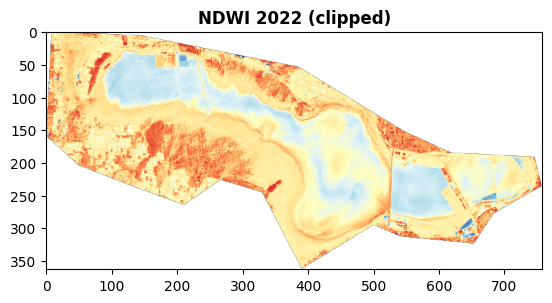

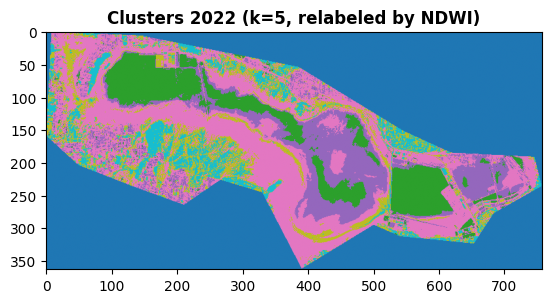

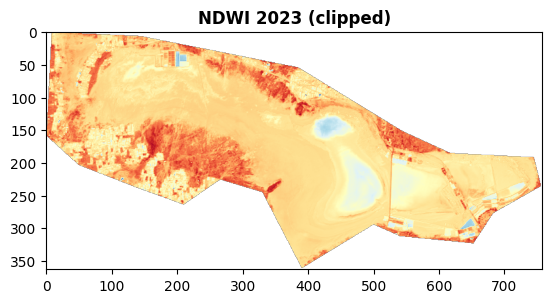

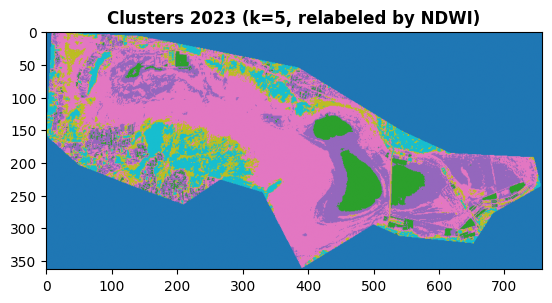

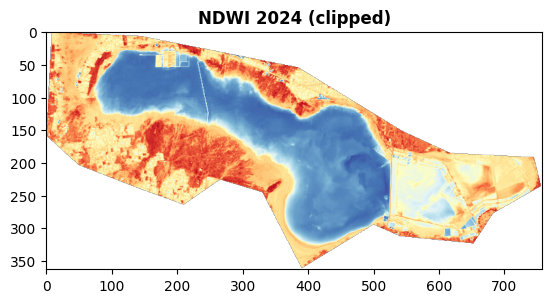

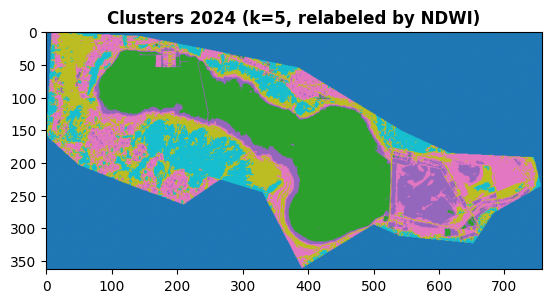

In [ ]:
for y in years:
    show(aligned[y], title=f"NDWI {y} (clipped)", cmap="RdYlBu")
    show(aligned_labels_by_year[y], title=f"Clusters {y} (k=5, relabeled by NDWI)", cmap="tab10")

## 11. Statistical Consolidation
Structuring tabular summaries correlating metrics, surface pixel counts, and precipitation attributes.

In [ ]:
rows = []
for y in years:
    arr = aligned[y]
    lab = aligned_labels_by_year[y]

    for c in range(k):
        rows.append({
            "year": y,
            "cluster": c,
            "mean_ndwi": float(np.nanmean(arr[lab == c])),
            "pixel_count": int(np.sum(lab == c))
        })

cluster_stats = pd.DataFrame(rows).merge(rain_by_year, on="year", how="left")
cluster_stats

,year,cluster,mean_ndwi,pixel_count,rain_mm
0,2022,0,0.277060,23274,33.98
1,2022,1,0.060583,26682,33.98
2,2022,2,-0.130205,56813,33.98
3,2022,3,-0.322699,21338,33.98
4,2022,4,-0.570367,14512,33.98
5,2023,0,0.101824,11706,23.63
6,2023,1,-0.056359,32352,23.63
7,2023,2,-0.131595,63970,23.63
8,2023,3,-0.259535,17411,23.63
9,2023,4,-0.400809,15999,23.63


In [ ]:
# Define fixed colors for clusters (match map + plots)
cluster_colors = {
    0: "#1f77b4",  # blue
    1: "#ff7f0e",  # orange
    2: "#2ca02c",  # green
    3: "#d62728",  # red
    4: "#9467bd",  # purple
}

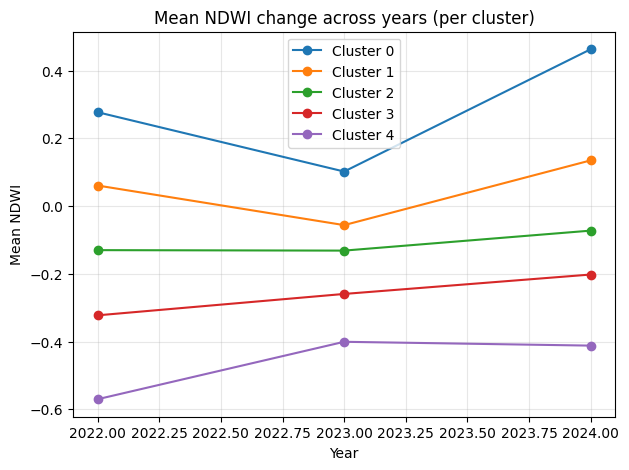

In [ ]:
plt.figure(figsize=(7,5))

for c in range(k):
    s = cluster_stats[cluster_stats.cluster == c].sort_values("year")
    plt.plot(
        s["year"],
        s["mean_ndwi"],
        marker="o",
        label=f"Cluster {c}",
        color=cluster_colors[c]
    )

plt.title("Mean NDWI change across years (per cluster)")
plt.xlabel("Year")
plt.ylabel("Mean NDWI")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

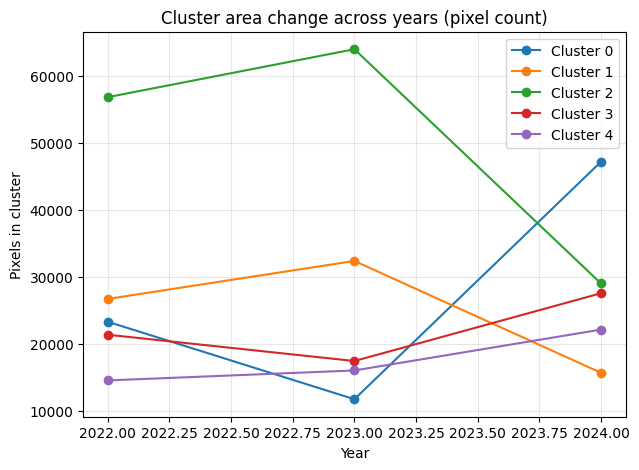

In [ ]:
plt.figure(figsize=(7,5))
for c in range(k):
    s = cluster_stats[cluster_stats.cluster == c].sort_values("year")
    plt.plot(s["year"], s["pixel_count"], marker="o", label=f"Cluster {c}")
plt.title("Cluster area change across years (pixel count)")
plt.xlabel("Year")
plt.ylabel("Pixels in cluster")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 12. Dynamic State Transition Modeling
Computing spatial transition matrices to explicitly identify pixel stability and geographical class conversion vectors across periods.

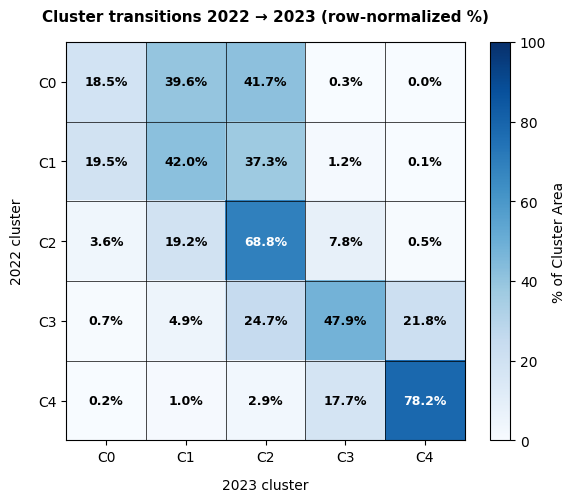

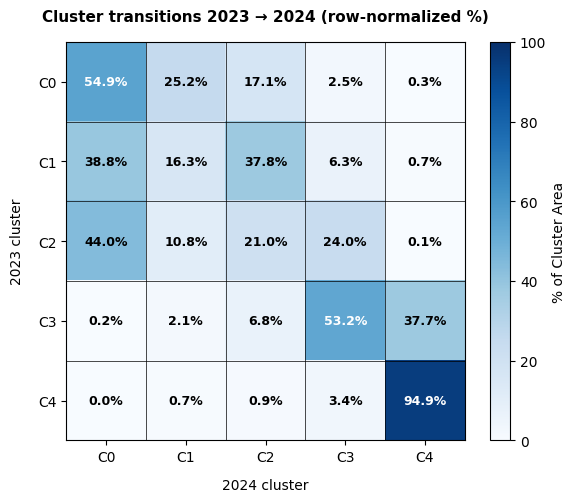

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def transition_matrix(labels_a, labels_b, k=5):
    """
    Returns:
      counts: kxk matrix where [i,j] = #pixels that were cluster i in A and cluster j in B
      perc_row: row-normalized percent matrix (rows sum to 100)
      perc_all: percent of all valid pixels matrix (sums to 100)
    """
    a = labels_a.reshape(-1)
    b = labels_b.reshape(-1)

    valid = (a >= 0) & (b >= 0)
    a = a[valid]
    b = b[valid]

    counts = np.zeros((k, k), dtype=np.int64)
    for i in range(k):
        for j in range(k):
            counts[i, j] = np.sum((a == i) & (b == j))

    row_sums = counts.sum(axis=1, keepdims=True)
    perc_row = np.divide(counts, row_sums, out=np.zeros_like(counts, dtype=float), where=row_sums!=0) * 100.0

    total = counts.sum()
    perc_all = (counts / total * 100.0) if total > 0 else counts.astype(float)

    return counts, perc_row, perc_all

def plot_heatmap(mat, title, xlabel, ylabel):
    plt.figure(figsize=(6, 5))

    # Using a clean blue sequential palette where dark blue = high transition/stability
    im = plt.imshow(mat, cmap="Blues", vmin=0, vmax=100)

    plt.title(title, fontsize=11, fontweight="bold", pad=15)
    plt.xlabel(xlabel, fontsize=10, labelpad=10)
    plt.ylabel(ylabel, fontsize=10, labelpad=10)

    plt.xticks(range(mat.shape[1]), [f"C{j}" for j in range(mat.shape[1])])
    plt.yticks(range(mat.shape[0]), [f"C{i}" for i in range(mat.shape[0])])

    # Add a crisp border around the grid cells
    ax = plt.gca()
    ax.set_xticks(np.arange(-.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, mat.shape[0], 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    plt.colorbar(im, label="% of Cluster Area")

    # Annotate values cleanly, making text white on dark squares so it stands out
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            color = "white" if mat[i, j] > 50 else "black"
            plt.text(j, i, f"{mat[i, j]:.1f}%", ha="center", va="center",
                     fontsize=9, color=color, fontweight="semibold")

    plt.tight_layout()
    plt.show()

years = sorted(aligned_labels_by_year.keys())
pairs = [(years[0], years[1]), (years[1], years[2])]

for y1, y2 in pairs:
    counts, perc_row, perc_all = transition_matrix(aligned_labels_by_year[y1], aligned_labels_by_year[y2], k=k)

    # Row-normalized heatmap: "given you were in cluster i, where did you go?"
    plot_heatmap(
        perc_row,
        title=f"Cluster transitions {y1} → {y2} (row-normalized %)",
        xlabel=f"{y2} cluster",
        ylabel=f"{y1} cluster"
    )

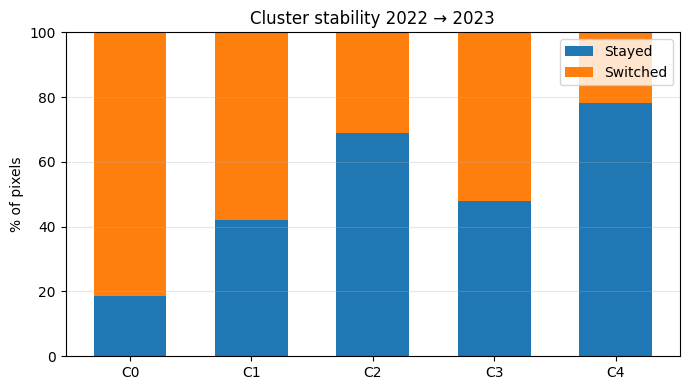

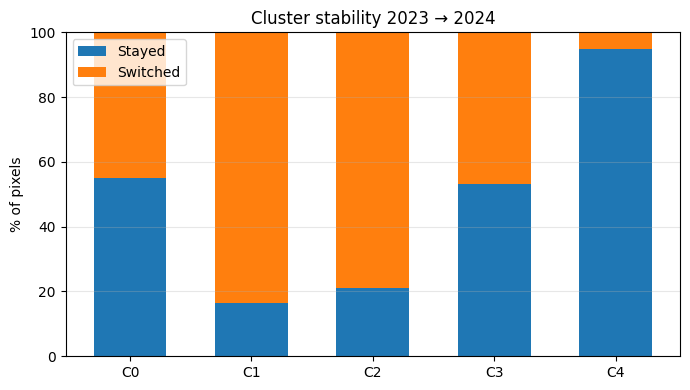

In [ ]:
def stayed_switched(labels_a, labels_b, k=5):
    a = labels_a.reshape(-1)
    b = labels_b.reshape(-1)
    valid = (a >= 0) & (b >= 0)
    a = a[valid]
    b = b[valid]

    stayed = np.zeros(k, dtype=int)
    total  = np.zeros(k, dtype=int)

    for i in range(k):
        idx = (a == i)
        total[i] = np.sum(idx)
        stayed[i] = np.sum(b[idx] == i)

    switched = total - stayed
    stayed_pct = np.divide(stayed, total, out=np.zeros_like(stayed, dtype=float), where=total!=0) * 100.0
    switched_pct = 100.0 - stayed_pct
    return stayed_pct, switched_pct

for y1, y2 in pairs:
    stayed_pct, switched_pct = stayed_switched(aligned_labels_by_year[y1], aligned_labels_by_year[y2], k=k)

    x = np.arange(k)
    width = 0.6

    plt.figure(figsize=(7,4))
    plt.bar(x, stayed_pct, width, label="Stayed")
    plt.bar(x, switched_pct, width, bottom=stayed_pct, label="Switched")
    plt.xticks(x, [f"C{i}" for i in range(k)])
    plt.ylim(0, 100)
    plt.ylabel("% of pixels")
    plt.title(f"Cluster stability {y1} → {y2}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()